In [2]:
import os
%load_ext autoreload
%autoreload 1
%aimport utility.functions
%aimport src.analysis
%aimport src.dataset
%aimport src.plots
%aimport src.simulation
import numpy as np
import utility.functions as fn
import src.simulation as sim
import src.analysis as an
import src.dataset as ds
import src.plots as plots
import torch
from scipy.stats import norm
import pandas as pd
from utility.double_beta_spectrum import pdf_ratio2b
import glob
import matplotlib.pyplot as plt
BASE = "../"
channels = [3, 5, 9, 11, 13, 15, 17, 19]
channel_ID = [5, 9, 11, 10, 4, 2, 12, 3]
StdCuts = [0.0003, 0.0004, 0.0008, 0.0006, 0.0012, 0.0007, 0.00035, 0.0025]

Main loop to compute the BI for all channels and acceptance levels

In [ ]:
import sys
from pathlib import Path
# Add src to Python path dynamically
BASE = Path(__file__).resolve().parent.parent
sys.path.append(str(BASE))
import time
import numpy as np
import src.analysis as an
import src.dataset as ds
import src.simulation as sim
from utility.double_beta_spectrum import pdf_ratio2b
import torch
from scipy.stats import norm
n_deriv = 0
window_size = 4096
meas_name = "000813_20230628T161508"
device = 'cuda' if torch.cuda.is_available() else 'cpu'
BIs = []
BI_uncertainties = []
channel_list = []
J_list = []
channels = [3, 5, 9, 11, 13, 15, 17, 19]
channel_ID = [5, 9, 11, 10, 4, 2, 12, 3]
StdCuts = [0.0003, 0.0004, 0.0008, 0.0006, 0.0012, 0.0007, 0.00035, 0.0025]
for channel, StdCut in zip(channels, StdCuts):
    meas_name = "000813_20230628T161508"
    meanpulse = np.fromfile(ds.find_file(f"{meas_name}_{channel:03}_???.bin_edmean.bin",
                                         specific_subdir="RUN9_pulse_injected_new/"))
    # Load datasets and channel specifications
    dataset_single_name = "pup_n1-d0_000813_20230628T161508"
    file_path_single, path_pos_single = ds.find_files(meas_name, dataset_single_name, channel,
                                                      specific_subdir="RUN9_pulse_injected_new/")
    data_single = ds.CachedBinaryDataset_withgenerated(file_path_single, path_pos_single, 4096,
                                                       pulse=meanpulse,
                                                       n_windows=15999, win_shift=0)

    dataset_pileup_name = "pup_n1-d8_000813_20230628T161508"
    file_path_pileup, path_pos_pileup = ds.find_files(meas_name, dataset_pileup_name, channel,
                                                      specific_subdir="RUN9_pulse_injected_new/")
    data_pileup = ds.CachedBinaryDataset_withgenerated(file_path_pileup, path_pos_pileup, 4096,
                                                       pulse=meanpulse,
                                                       n_windows=15999, win_shift=0)
    # data_single, data_pileup = ds.create_data_sets_denoise(channel, win_length=2000, shift=0, pos_prefix="_bis")
    nps_bis = np.load(f"{BASE}/outputs/NPS_study/NPS_channel{channel}_win{window_size}_{meas_name}.npy")
    nps_bis *= (8. / 3.)  # Adjust for Hann window effect

    meanpulse_bis = meanpulse[np.argmax(meanpulse) - window_size // 2:np.argmax(meanpulse) + window_size // 2]
    signal_amp = ds.get_amp_Q_val(channel)

    # Loop over acceptance levels
    # acceptances = [0.7, 0.8, 0.84, 0.87, 0.9, 0.92, 0.93, 0.94, 0.95, 0.96, 0.99]
    acceptances = [0.9]
    for acceptance in acceptances:
        N_sigma = norm.ppf(1 - (1 - acceptance) * 100 / 100)
        S, w, H_unit = an.compute_H(meanpulse_bis, nps_bis, np.hanning)
        # Convert all arrays to torch tensors on GPU
        S_torch = torch.tensor(S, dtype=torch.cfloat, device=device)
        H_unit_torch = torch.tensor(H_unit, dtype=torch.cfloat, device=device)
        w_torch = torch.tensor(w, dtype=torch.cfloat, device=device)
        nps_torch = torch.tensor(nps_bis, dtype=torch.cfloat, device=device)
        signal_amp_torch = torch.tensor(signal_amp, dtype=torch.float32, device=device)

        t_min, t_max, N_t = 0, 8e-4, 150
        r_min, r_max, N_r = 0., .5, 75
        ratio_distribution = pdf_ratio2b(np.linspace(r_min, r_max, N_r))
        ratio_distribution /= np.mean(ratio_distribution)

        t_torch = torch.linspace(t_min, t_max, N_t, dtype=torch.cfloat, device=device)
        r_torch = torch.linspace(r_min, r_max, N_r, dtype=torch.cfloat, device=device)
        ratio_distribution_torch = torch.tensor(ratio_distribution, dtype=torch.cfloat, device=device)

        # f1_opt, f2_opt, J_values = an.optimize_filters(S_torch, H_unit_torch, w_torch, t_torch, r_torch, nps_torch,
        #                                                signal_amp_torch, ratio_distribution_torch, N_sigma=N_sigma,
        #                                                n_trials=1000, verbose=False)
        f1_opt, f2_opt = np.load(f"../outputs/Pileup_filter_functions/channel_{channel}/functions_eff{int(acceptance*100):d}_d0.npy")
        # np.save(f"{BASE}/outputs/training_Js/channel_{channel}/J_{int(acceptance * 100):d}_base", np.array(J_values))
        # np.save(f"{BASE}/outputs/Pileup_filter_functions/channel_{channel}/functions_eff{int(acceptance * 100):d}_base",
        #         np.array([f1_opt, f2_opt]))
        f1_t = torch.tensor(f1_opt, dtype=torch.float32, device=device)
        f2_t = torch.tensor(f2_opt, dtype=torch.float32, device=device)

        # S_H_delayed, S_H, S2_over_nps = an.precompute_constants(S_torch, H_unit_torch, w_torch, t_torch, nps_torch)
        # 
        # f1_t /= torch.mean(f1_t * S_H).real
        # f2_t /= torch.mean(f2_t * S_H).real
        # 
        # S_H_delayed, S_H, S2_over_nps = an.precompute_constants(S_torch, H_unit_torch, w_torch, t_torch, nps_torch)
        # J = an.compute_J(f1_t, f2_t, S_H_delayed, r_torch, S_H, S2_over_nps, signal_amp_torch, ratio_distribution_torch,
        #                  N_sigma=N_sigma, full_output=False, use_interp=True)


        # Compute PSD and BI
        BI, rp, sigma_rp, sigma_BI = an.compute_BI_torch(
            data_pileup,
            data_single,
            acceptance,
            H_unit_torch,
            f1_t,
            f2_t,
            window_fct = np.hanning,
            n_deriv = 0,
            compute_uncertainty = True,
            batch_size = 2048,
            use_loader = False
        )
        # BIs.append(float(BI))
        # BI_uncertainties.append(float(sigma_BI))
        # channel_list.append(channel)
        # J_list.append(J.cpu().numpy())
        print(f"Channel {channel}, 1-rp={1 - rp}, BI={BI}")

        data = np.column_stack([channel_list, BIs, BI_uncertainties,J_list])
        header = "channel,BI,BI_err,J"

        np.savetxt(
            f"{BASE}/outputs/BI_results_base.csv",
            data,
            delimiter = ",",
            header = header,
            comments = ""
        )


In [ ]:
import glob
import matplotlib as mpl
files = glob.glob(os.path.join("../outputs/","**", "BI_channel_**_varying_grid_size.csv"), recursive = True)
for i,file in enumerate(files):
    df = pd.read_csv(file)
    plt.plot(df["grid_N"], df["1-rp"],marker='o')
    plt.plot(df["grid_N"], df["J"],marker='o')
    plt.show()
files = glob.glob(os.path.join("../outputs/","**", "J_90_N_grid_**.npy"), recursive = True)
cmap = plt.get_cmap("viridis")
grid_Ns = []
for i,file in enumerate(files):
    channel = int(file.split("channel_")[1].split("/")[0])
    grid_N = int(file.split("N_grid_")[1].split(".npy")[0])
    grid_Ns.append(grid_N)
    J_values = np.load(file)
    plt.plot(np.arange(len(J_values)), J_values, label=f"Channel {channel} grid N {grid_N}",c=cmap(i/len(files)))
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=mpl.colors.Normalize(vmin=min(grid_Ns), vmax=max(grid_Ns)))
cbar = plt.colorbar(sm, pad=0.01)
plt.show()
files = glob.glob(os.path.join("../outputs/","**", "functions_eff90_N_grid_**.npy"), recursive = True)
cmap = plt.get_cmap("viridis")
for i,file in enumerate(files):
    channel = int(file.split("channel_")[1].split("/")[0])
    grid_N = int(file.split("N_grid_")[1].split(".npy")[0])
    f1,f2 = np.load(file)
    window_size = len(f1)
    plt.plot(np.fft.fftfreq(window_size,1e-4)[:window_size//2], f1[:window_size//2], label=f"Channel {channel} grid N {grid_N}",c=cmap(i/len(files)),alpha=0.5)
    plt.plot(np.fft.fftfreq(window_size,1e-4)[:window_size//2], f2[:window_size//2], c=cmap(i/len(files)),alpha=0.5)

In [ ]:
single_pulse_indexes =  [[126, 47, 77],
                         [394, 390, 240],
                         [33, 334, 322],
                         [71, 312, 199],
                         [101, 233, 71],
                         [253, 52, 147],
                         [238, 103, 6],
                         [295, 67, 199]]
channel = 19
pos_pulses = np.load(f"{BASE}/outputs/meanpulses_build/pos_pulses_rawdata/pos_pulses_channel_{channel}.npy")
file_name = ds.find_file(f"000813_20230628T161508_{channel:03}_000.bin")
dataset_pulse = ds.CachedBinaryDataset(file_name,window_size,positions=pos_pulses,win_shift_start = -window_size//2)
pulses_min_baseline = (dataset_pulse.data-dataset_pulse.data[:, :window_size//2-48].mean(dim=1,keepdim = True))
normalize_amp = torch.max(pulses_min_baseline,dim=1).values/ds.get_amp_Q_val(channel)
index = single_pulse_indexes[channels.index(channel)][0]
# plt.plot(pulses_min_baseline[index]/torch.max(pulses_min_baseline[index]),label='Selected pulse 0')
plt.loglog(np.abs(np.fft.fft(pulses_min_baseline[index]/torch.max(pulses_min_baseline[index]))),label='Selected pulse 0')
index = single_pulse_indexes[channels.index(channel)][1]
# plt.plot(pulses_min_baseline[index]/torch.max(pulses_min_baseline[index]),label='Selected pulse 1')
plt.loglog(np.abs(np.fft.fft(pulses_min_baseline[index]/torch.max(pulses_min_baseline[index]))),label='Selected pulse 1')
index = single_pulse_indexes[channels.index(channel)][2]
# plt.plot(pulses_min_baseline[index]/torch.max(pulses_min_baseline[index]),label='Selected pulse 2')
plt.loglog(np.abs(np.fft.fft(pulses_min_baseline[index]/torch.max(pulses_min_baseline[index]))),label='Selected pulse 2')
plt.legend()
plt.show()

In [ ]:

rms_s = np.array([29,35,40,50,70,95,23,18,16-1.3])*1e-5
signal_amps =  [0.028,  0.033,  0.035,  0.035,   0.04,  0.031,  0.022,  0.018,  0.015]
measurements = [779,    780,    781,    782,    783,    784,    785,    786,    787]
channel = 3

# channel = 5
# measurements = [767,768,769,770,771,772,773,774,775]
# rms_s = np.array([3,3.5,4,5,6.5,8,2.7,2.2,1.9])*1e-4
# signal_amps = [0.085,0.1,0.11,0.13,0.143,0.137,0.063,0.047,0.039]
len_d = 450
popts = []
fig,ax2 = plt.subplots(1,figsize=(10,6))
popt_list = []
signal_amps_meas = []
fs_val = 5000
NTL_amp = 0
nps_s = []
biais_current = [2.89,2.036,1.57,1.0,0.549,0.279,4.8383,7.696,10]

for meas in measurements:
    signal_amp = signal_amps[measurements.index(meas)]
    rms_thr = rms_s[measurements.index(meas)]
    file_name = ds.find_file(f"000{meas}*_{channel:03}_000.bin")
    dataset = ds.CachedBinaryDataset(file_name,2048,positions=2048*np.arange(len_d,dtype=int)+2)
    nps = an.create_NPS_torch(dataset,n_deriv=0,rms_thr=rms_thr, batch_size=2048, window_fct=np.hanning,
                                          use_loader=False, device='cpu').astype(np.float64)
    #nps.tofile(f"../outputs/NPS_study/NPS_measurement_{meas}_channel{channel}.bin")
    
    sel = torch.std(dataset.data,dim=1).numpy()>rms_thr*5
    trigpos = dataset.data[sel].argmax(dim=1) + np.argwhere(sel)[:,0]*2048 + 2
    trigpos = trigpos[torch.diff(trigpos,prepend =torch.tensor([-torch.inf]))>2000]
    dataset_pulse = ds.CachedBinaryDataset(file_name,2048,positions=trigpos.numpy(),win_shift_start = -1024)
    mean_pulse, pulses = an.build_mean_pulse_filteralignement_from_raw(dataset_pulse, rms_thr = rms_thr,
                                                              nps = nps, batch_size = 2048,
                                                              pulse_start_pos=-100, pulse_end_pos=4096,
                                                              amplitude_bounds=(signal_amp-0.01,signal_amp+0.01),
                                                              return_amp = False,return_pulses = True,
                                                              device = 'cpu', use_loader = False)
    #mean_pulse.numpy().tofile(f"../outputs/meanpulses_build/meanpulse_measurement_{meas}_channel{channel}.bin")


In [ ]:

channels = [3,5,9,11,13,15,17,19]
window_size = 4096
len_d = 1024*4
# meas = 815
# rms_thr_list =np.array([2.4,3.0,6.4,7.0,7.0,5.5,3.3,18])*1e-4
meas = 830
rms_thr_list =np.array([1.94,2.4,4.2,4.0,3.4,3.6,2.7,14])*1e-4
for channel in channels:
    file_name = ds.find_file(f"000{meas}*_{channel:03}_000.bin")
    dataset = ds.CachedBinaryDataset(file_name,window_size,positions=window_size*np.arange(len_d,dtype=int)+2)
    # stds = torch.std(dataset.data,dim=1).numpy()*1e4
    # print(np.percentile(stds,1),np.percentile(stds,90))
    # plt.hist(stds,bins=100,range=(np.percentile(stds,1),np.percentile(stds,90)),alpha=0.5,label=f"Channel {channel}")
    # plt.show()
    rms_thr = rms_thr_list[channels.index(channel)]
    nps = an.create_NPS_torch(dataset,n_deriv=0,rms_thr=rms_thr, batch_size=2048, window_fct=np.hanning,
                                          use_loader=False, device='cpu').astype(np.float64)
    sel = torch.std(dataset.data,dim=1).numpy()>rms_thr*5
    trigpos = dataset.data[sel].argmax(dim=1) + np.argwhere(sel)[:,0]*window_size + 2
    trigpos = trigpos[torch.diff(trigpos,prepend =torch.tensor([-torch.inf]))>window_size*2]
    dataset_pulse = ds.CachedBinaryDataset(file_name,window_size,positions=trigpos.numpy(),win_shift_start = -window_size//2)
    mean_pulse, pulses = an.build_mean_pulse_filteralignement_from_raw(dataset_pulse, rms_thr = rms_thr,
                                                              nps = nps, batch_size = 2048,
                                                              pulse_start_pos=-100, pulse_end_pos=2048,
                                                              amplitude_bounds=(0.1,5),
                                                              return_amp = False,return_pulses = True,
                                                              device = 'cpu', use_loader = False)
    pulses_norm = pulses/torch.max(pulses,dim=1).values[:,None]
    chi2 = torch.mean((pulses_norm-mean_pulse)**2,dim=1)
    pulses_norm = pulses_norm[chi2<0.0002]
    mean_pulse = torch.mean(pulses_norm,dim=0)
    # plt.plot(pulses_norm.T,color='gray',alpha=0.3)
    # plt.plot(mean_pulse,label=f"Channel {channel}")
    # 
    # plt.xlim(1800,2700)
    # plt.show()
    nps.astype(np.float64).tofile(f"../outputs/NPS_study/NPS_measurement_{meas}_channel{channel}.bin")
    mean_pulse.numpy().astype(np.float64).tofile(f"../outputs/meanpulses_build/meanpulse_measurement_{meas}_channel{channel}.bin")
    fig,(ax1,ax2) = plt.subplots(1,2,figsize=(12,5))
    ax1.loglog(np.fft.rfftfreq(window_size,1e-4),nps[:window_size//2+1],label=f"Channel {channel}")
    ax1.set_title(f"NPS Channel {channel}")
    ax1.set_xlabel("Frequency (Hz)")
    ax1.set_ylabel("NPS (a.u.)")
    ax1.legend()
    ax2.loglog(np.fft.rfftfreq(window_size,1e-4),np.abs(np.fft.fft(mean_pulse))[:window_size//2+1],label=f"Channel {channel}")
    

In [ ]:
mp = np.load("../outputs/meanpulses_build/channel3_meanpulse_raw.npy")
mp = mp/np.max(mp)
plt.plot(np.arange(-len(mp)//2,len(mp)//2)*1e-1,mp, label='Normalized Pulse event')
plt.fill_betweenx(np.array([-0.11,1.1]),-8e-1,8e-1,color='red',alpha=0.3, label='$\Delta t$ window : [-0.8 ms, 0.8 ms]')
plt.xlim(-5,20)
plt.ylim(-0.04,1.1)
plt.yticks([])
plt.legend(fontsize=12)
plt.xlabel("Time (ms)", fontsize=14)
plt.xticks(fontsize=12)
plt.show()

In [ ]:
measurements = [779,    780,    781,    782,    783,    784,    785,    786,    787]# + [767,768,769,770,771,772,773,774,775]
bias_current = [2.89,2.036,1.57,1.0,0.549,0.279,4.8383,7.696,10]#+ [4.8383,7.696,10,2.89,2.036,1.57,1.0,0.549,0.279]
channel = 3
fig,ax = plt.subplots(1,1,figsize=(12,9))
ref_LED_amp = [0.032891195]*9 + [0.13]*9
ref_sensitivity_list = [1.4]*9 + [2.0]*9
Gains_80V_list = [13.6]*9 + [10.6]*9
NTL_noise_factor_list = [1e-7] *9 + [0.3e-7]*9
for idx in np.argsort(bias_current):
    meas,b = measurements[idx], bias_current[idx]
    # signal_amp = ref_amplitude * WP_gain * Gains_80V
    mean_pulse_filtered = np.fromfile(f"{BASE}/outputs/meanpulses_build/meanpulse_measurement_{meas}_channel{channel}.bin")
    nps = (np.fromfile(f"{BASE}/outputs/NPS_study/NPS_measurement_{meas}_channel{channel}.bin"))
    l,= plt.loglog(np.fft.rfftfreq(len(mean_pulse_filtered),1e-4),nps[:len(mean_pulse_filtered)//2+1],label=f"{b} nA")
    plt.loglog(np.fft.rfftfreq(len(mean_pulse_filtered),1e-4),np.abs(np.fft.fft(mean_pulse_filtered))[:1025],c=l.get_color())
plt.xlabel("Frequency (Hz)")
plt.ylabel("NPS (a.u.)")
plt.legend()


In [ ]:
measurements = [767,768,769,770,771,772,773,774,775]
channel = 5
fig,ax = plt.subplots(1,1,figsize=(12,9))
ref_LED_amp = [0.032891195]*9 + [0.13]*9
ref_sensitivity_list = [1.4]*9 + [2.0]*9
Gains_80V_list = [13.6]*9 + [10.6]*9
NTL_noise_factor_list = [1e-7] *9 + [0.3e-7]*9
for idx in np.argsort(bias_current):
    meas,b = measurements[idx], bias_current[idx]
    # signal_amp = ref_amplitude * WP_gain * Gains_80V
    mean_pulse_filtered = np.fromfile(f"{BASE}/outputs/meanpulses_build/meanpulse_measurement_{meas}_channel{channel}.bin")
    nps = (np.fromfile(f"{BASE}/outputs/NPS_study/NPS_measurement_{meas}_channel{channel}.bin"))
    l,= plt.loglog(np.fft.rfftfreq(len(mean_pulse_filtered),1e-4),nps[:len(mean_pulse_filtered)//2+1],label=f"{b} nA")
    plt.loglog(np.fft.rfftfreq(len(mean_pulse_filtered),1e-4),np.abs(np.fft.fft(mean_pulse_filtered))[:1025],c=l.get_color())
plt.xlabel("Frequency (Hz)")
plt.ylabel("NPS (a.u.)")
plt.legend()

In [ ]:
LED_amp = ([0.028401334, 0.032891195, 0.035842195, 0.038979053, 0.03883822, 0.031177562, 0.021730503, 0.016601065, 0.0141078625]+
           [0.085,0.1,0.11,0.13,0.143,0.137,0.063,0.047,0.039])

In [ ]:
plt.scatter(bias_current,[0.028401334, 0.032891195, 0.035842195, 0.038979053, 0.03883822, 0.031177562, 0.021730503, 0.016601065, 0.0141078625],label ="Channel 3, detector 5")
plt.scatter(bias_current,[0.085,0.1,0.11,0.13,0.143,0.137,0.063,0.047,0.039],label ="Channel 5, detector 9")
plt.legend()

In [ ]:
df = pd.read_csv(f"../outputs/Systematics/BI_WP.csv")
df["BI"] = fn.K * df["J_value"]*1e5
df


In [ ]:
file_name = ds.find_file(f"000{meas}*_{channel:03}_000.bin")
len(ds.load_binary_file(file_name))/5000

In [ ]:
channels = [3, 5, 9, 11, 13, 15, 17, 19]

f1_all, f2_all = [], []
fn.K
fig, ax = plt.subplots(figsize = (8, 6))

for ch in channels:
    f1, f2 = np.load(f"../outputs/Pileup_filter_functions/channel_{ch}/functions_eff90_V2.npy")
    freq = np.fft.fftfreq(len(f1), d = 1e-4)
    l,=ax.loglog(freq[:1000], f1[:1000], alpha = 0.1)
    ax.loglog(freq[:1000], f2[:1000], alpha = 0.5, color = l.get_color())
    ax.axvline(freq[np.where((np.mean(f2[800:1000])-f2[:1000])>0)[0][0]], color = l.get_color())
    print(freq[np.argmax(f1)],np.max(f1))
    #print(np.mean(f2[800:1000]),freq[np.where((np.mean(f2[800:1000])-f2[:1000])>0)[0][0]])

In [ ]:
df = pd.read_csv("../outputs/BI_results_base.csv")
df["detector_id"] = df["channel"].apply(lambda x: channel_ID[channels.index(x)])

df.sort_values("detector_id",inplace = True)
df["BI"]*=1e5
df["BI_uncertainty"]*=1e5
df["BI"].mean()

In [ ]:
np.mean([8.4,8.4,6.0,6.7,7.4,6.4,7.0,7.0])
# np.mean([10.2,10.1,6.7,6.8,7.8,7.8,7.7,8.3,7.8])

In [ ]:
(7.16-5.64)/7.16*100

In [ ]:
fig, ax = plt.subplots(figsize = (8, 6))
f1_all, f2_all = [], []
for ch in channels:
    f1, f2 = np.load(f"../outputs/Pileup_filter_functions/channel_{ch}/functions_eff90_base_true_mp.npy")
    f1_all.append(np.abs(f1))
    f2_all.append(np.abs(f2))

    freq = np.fft.fftfreq(len(f1), d = 1e-4)
    pos_freq = freq > 0
    gain_1000 = f1[freq>1000][0]
    gain_3000 = f1[freq>3000][0]
    db_1000 = 20*np.log10(gain_1000)
    db_3000 = 20*np.log10(gain_3000)
    change_db = db_3000 - db_1000
    freq_ratio = 3000 / 1000
    decades = np.log10(freq_ratio)
    print(change_db/decades, np.max(f1), ch)
    
    ax.plot(freq[pos_freq], f1[pos_freq], alpha = 0.1, color = "k")
    ax.plot(freq[pos_freq], f2[pos_freq], alpha = 0.1, color = "k")
from scipy.stats import pearsonr
ax.set_xscale("log")
ax.set_yscale("log")
gains_m1 = np.array(f1_all)
median_m1 = np.median(gains_m1, axis = 0)
r_squared_values = []
for detector_gains in gains_m1:
    r, _ = pearsonr(detector_gains, median_m1)
    r_squared_values.append(r**2)
mean_r2 = np.mean(r_squared_values)
gains_m2 = np.array(f2_all)
median_m2 = np.median(gains_m2, axis = 0)
print(f"Mean R² with median: {mean_r2:.3f}")
r_squared_values = []
for detector_gains in gains_m2:
    r, _ = pearsonr(detector_gains, median_m2)
    r_squared_values.append(r**2)
mean_r2 = np.mean(r_squared_values)
print(f"Mean R² with median: {mean_r2:.3f}")

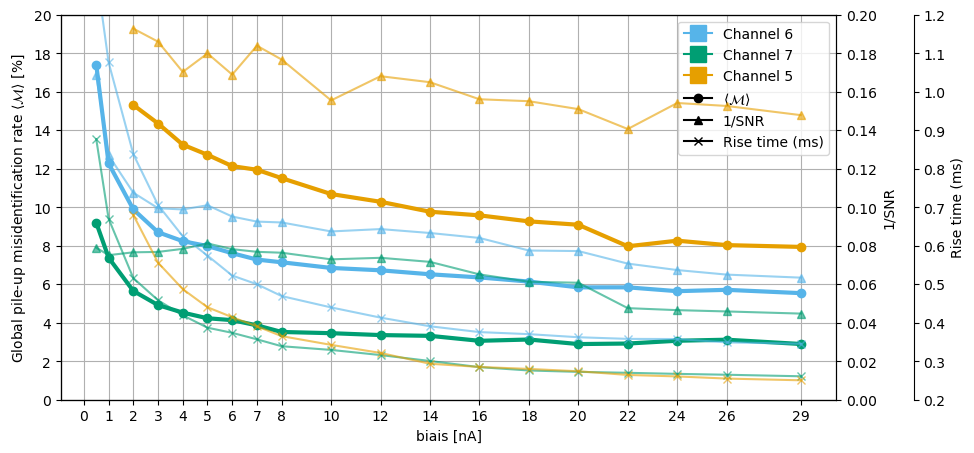

In [227]:
df = pd.read_csv(f"{BASE}/outputs/Systematics/BI_WP_RUN121_Ulysse.csv")
df_info = pd.read_csv("/media/mp274748/Transcend/data/Ulysse/RUN121/rms_amp_SNR_RUN121_bis.csv")
fig,ax1 = plt.subplots(figsize=(10,5))
ax2 = ax1.twinx()
ax3 = ax1.twinx()
ax3.spines.right.set_position(("axes", 1.1))

biais = np.array([0.5,1,2,3,4,5,6,7,8,10,12,14,16,18,20,22,24,26,29])
colors = [
        "#F0E442",  # yellow
        "#56B4E9",  # sky blue
        "#009E73",  # bluish green
        "#E69F00",  # orange
        "#0072B2",  # blue
        "#D55E00",  # vermillion
        "#000000",  # black
        "#CC79A7"  # reddish purple
    ]
for idx , channel in enumerate(df["channel"].unique()):
    if channel == 2:
        continue
    df_sub = df.loc[df["channel"]==channel]
    df_info_sub = df_info.loc[df_info["channel"]==channel]
    ax2.plot(biais[df_info_sub["meas"].astype(int)-1],1/df_info_sub["SNR"],c=colors[idx],marker='^',alpha=0.6)
    ax1.plot([],[],marker='s',label=f'Channel {int(channel)}',c=colors[idx],ms=12)
    ax3.plot(biais[df_info_sub["meas"].astype(int)-1],df_info_sub["rt"]*1000,c=colors[idx],marker='x',alpha=0.6)
for idx , channel in enumerate(df["channel"].unique()):
    if channel == 2:
        continue 
    df_sub = df.loc[df["channel"]==channel]
    df_info_sub = df_info.loc[df_info["channel"]==channel]
    l,=ax1.plot(biais[df_sub["measurement"].astype(int)-1],df_sub["J_value"]*100,marker='o',lw=3,c=colors[idx])
ax1.plot([],[],marker='o',label=r'$\langle \mathcal{M} \rangle$',c="k")
ax1.plot([],[],marker='^',label=f'1/SNR',c="k")
ax1.plot([],[],marker='x',label=f'Rise time (ms)',c="k")
ax1.set_xlabel("biais [nA]")
ax1.set_ylabel(r"Global pile-up misidentification rate $\langle \mathcal{M} \rangle$ [%]")
ax2.set_ylabel("1/SNR")
ax3.set_ylabel("Rise time (ms)")
ax1.set_xticks(biais.astype(int))
ax1.legend()
ax1.set_ylim(0,20)
ax1.set_yticks(np.arange(0,21,2))
ax2.set_ylim(0,0.02)
ax2.set_yticks(np.arange(0,0.21,0.02))
ax3.set_ylim(0.2,1.2)
ax3.set_yticks(np.arange(0.2,1.21,0.1))
ax1.grid()
fig.savefig("/local/home/mp274748/Documents/these/figures/BI_vs_bias_current_RUN121.pdf", dpi = 300)

In [ ]:
df_info

2.7550926208496094
2.633192300796509
2.344337224960327
2.04004430770874
1.7840365171432495
1.6119991540908811
1.4477810859680176
1.3228771686553955
1.1357855796813965
1.0013419389724731
0.8915526270866394
0.795964777469635
0.7334696054458618
0.6806741952896118
0.6754465699195862
0.6235311627388
0.5771634578704834
0.5319356322288513


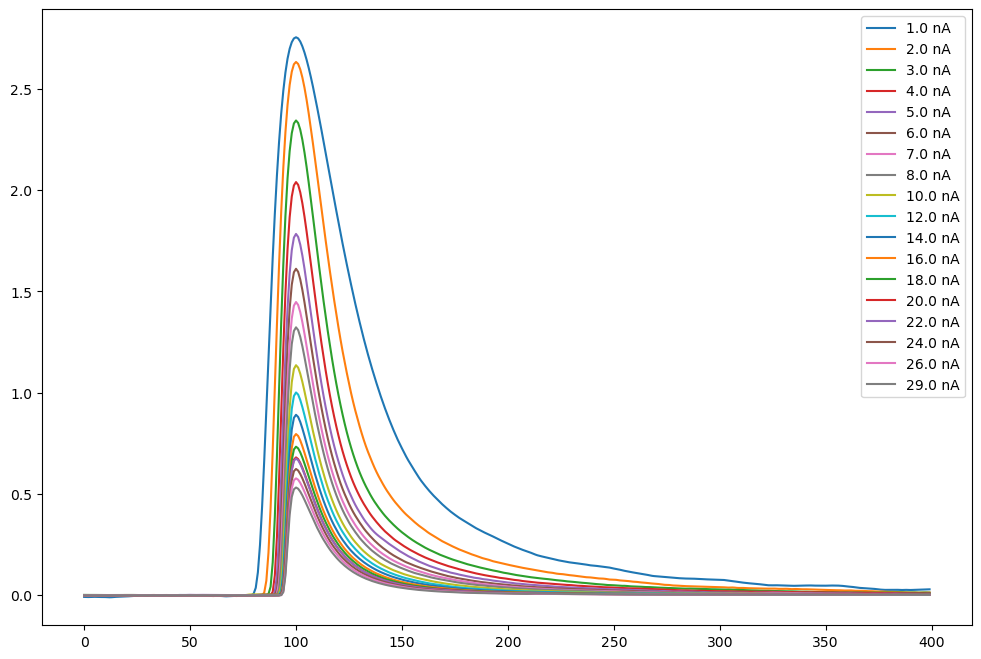

In [200]:
fig,ax1 = plt.subplots(figsize=(12,8))
biais = np.array([0.5,1,2,3,4,5,6,7,8,10,12,14,16,18,20,22,24,26,29])
for i in range(2,20):
    df_sub = df_info.loc[df_info["channel"]==6]
    amp=df_sub.loc[df_sub["meas"]==i,"amp_max"].values[0]
    print(amp)
    nps = np.load(glob.glob(f"/media/mp274748/Transcend/data/Ulysse/RUN121/NPS_RUN121_0000{i:02}_**_006_000.npy")[0])
    mp = nps = np.load(glob.glob(f"/media/mp274748/Transcend/data/Ulysse/RUN121/MP_RUN121_0000{i:02}_**_006_000.npy")[0])
    # plt.loglog(np.fft.rfftfreq(4096,1/10000),nps[:2049],label=f"{biais[i-1]} nA")
    plt.plot(amp*mp[2048-100:2048+300],label=f"{biais[i-1]} nA")
plt.legend()

In [ ]:
from scipy.interpolate import interp1d
mp = np.load("../outputs/meanpulses_build/channel3_meanpulse_raw.npy")
mp = mp / np.max(mp)
mp_interp = interp1d(np.arange(len(mp)), mp, kind = 'cubic')
mp = mp_interp(np.linspace(0, len(mp) - 1, 10000))
fig, ax = plt.subplots(1, 1, figsize = (8, 6))
ax.plot(np.arange(- np.argwhere(mp>1e-2)[0], len(mp) - np.argwhere(mp>1e-2)[0]) * 4096 / 10000 * 1e-1, mp,
        label = 'Pulse impulse response s(t)',color="black")
ax.fill_betweenx(np.array([-0.11, 1.1]), -0e-1, 8e-1, color = 'green', alpha = 0.3,
                 label = '$\Delta t$ window: 0.8 ms')
ax.set_xlim(-5, 20)
ax.set_ylim(-0.04, 1.1)
plt.yticks(fontsize = 20)
plt.legend(fontsize = 19)
ax.set_xlabel("Time (ms)", fontsize = 20)
plt.xticks(fontsize = 20)
plt.xticks(np.arange(-5,20,1),minor=True)
plt.yticks(np.arange(-0.1,1,0.1),minor=True)
ax.grid(linestyle = '--', linewidth = 1)
ax.grid(which='minor', linestyle=':', linewidth=0.5)
fig.set_tight_layout(True)
fig.savefig("/local/home/mp274748/Documents/paper/pile_up_cupid/figures/meanpulse_with_dt_range.pdf", dpi = 300)
plt.show()


In [ ]:
df = pd.read_csv("../outputs/Systematics/BI_varying_grid_size.csv")
for channel in df["channel"].unique():
    df_sub = df.loc[df["channel"]==channel]
    plt.plot(df_sub["grid_N"],(df_sub["BI"]-df_sub["J"]*fn.K)/(df_sub["BI"]+df_sub["J"]*fn.K)*200,marker='o',label=f"Channel {channel}")
    
plt.ylabel("Relative difference\n(simulated − analytical BI) [%]")
plt.xlabel("Grid size N")

In [ ]:
df = pd.read_csv("../outputs/Systematics/BI_varying_grid_size.csv")
df = df[df["grid_N_t"]>2]
for channel in df["channel"].unique():
    df_sub = df.loc[df["channel"]==channel]
    plt.errorbar(df_sub["grid_N_t"],df_sub["BI"],df_sub["BI_uncertainty"],marker='o',label=f"Channel {channel}",ls="")
plt.xticks(df_sub["grid_N_t"][::2])
plt.xlabel("Grid size N")
plt.ylabel("BI [1e-5 cts/keV/kg/year]")
plt.grid()

In [ ]:
df["detector_id"] = df["channel"].apply(lambda x: channel_ID[channels.index(x)])
df.sort_values("detector_id", inplace=True)
df[df["grid_N"]==100]

In [ ]:
df = pd.read_csv("../outputs/Systematics/BI_varying_grid_size.csv")
df = df[df["grid_N_t"] == 100]
df["detector_id"] = df["channel"].apply(lambda x: channel_ID[channels.index(x)])
df["BI"]*=1e5
df.sort_values("detector_id", inplace=True)
df

In [ ]:
df = pd.read_csv("../outputs/Systematics/BI_varying_grid_size_full_channel3.csv")
df = df[df["channel"] == 3]
df = df[(df["grid_N_t"]>9)&(df["grid_N_r"]>9)]

heatmap_data = df.pivot(index="grid_N_t", columns="grid_N_r", values="BI")

plt.imshow(heatmap_data, origin="lower", aspect="auto",interpolation = "bilinear",cmap="viridis")
plt.colorbar(label="J")

plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns.astype(int),rotation=40)
plt.yticks(range(len(heatmap_data.index)), heatmap_data.index.astype(int),rotation=40)

plt.xlabel("grid_N_r")
plt.ylabel("grid_N_t")
plt.title("Grid Search Heatmap of J")

plt.show()


In [ ]:
files = glob.glob(f"{BASE}/outputs/**/BI_**.csv",recursive=True)
old_K = fn.calculate_K_factor(Activity = 3.09E-03,  # Activity in Bq (N/s)
                        LMO_MASS = 0.308,  # Mass of LMO in kg
                        second_in_year = 3600 * 24 * 365,  # Number of seconds in a year
                        Probability = 3.41E-04,  # Given probability factor
                        correction_factor = 1,  # Factor for corrections
                        dt = 0.8 , # Example exposure time in seconds
                        milliseconds_in_second = 1000)
import ast
for file in files:
    df = pd.read_csv(file, converters={"popt": ast.literal_eval})
    
    if "BI" in df.columns:
        df["BI"] *= fn.K/old_K
    if "BI_uncertainty" in df.columns:
        df["BI_uncertainty"] *= fn.K/old_K
    if "BI_err" in df.columns:
        df["BI_err"] *= fn.K/old_K
        df.rename(columns={"BI_err": "BI_uncertainty"})
    df.to_csv(file, index=False)

In [ ]:
meas_name = "000813_20230628T161508"

global_std = [0.00021900556748732924, 0.00028078060131520033, 0.00047128828009590507, 0.0003684174735099077, 0.0005077228997834027, 0.0004087088746018708, 0.0002996263501700014, 0.0011633249232545495]
for channel in channels:
    std_factor = global_std[channels.index(channel)]
    data_path = ds.find_file(f"{meas_name}_{channel:03}_???.bin",
                                         specific_subdir="RUN9_pulse_injected_new/")
    pos_path = ds.find_file(f"pup_n1-d0_{meas_name}_{channel:03}_???_bis.pt",
                                         specific_subdir="RUN9_pulse_injected_new/")
    pos = torch.load(pos_path,weights_only=True).numpy()
    correction_file = ds.find_file(f"pulses_pred_d0_{channel:03}.npy",
                                         specific_subdir="RUN9_pulse_injected_new/")
    correction = np.load(correction_file)
    dataset_single_name = "pup_n1-d0_000813_20230628T161508"
    file_path_single, path_pos_single = ds.find_files(meas_name, dataset_single_name, channel,
                                                          specific_subdir = "RUN9_pulse_injected_new/")
    n_wind = min(len(pos),len(correction))
    window_size = 2048
    data = ds.CachedBinaryDataset_withdenoise(data_path,path_pos_single, win_length=window_size, positions=pos[:n_wind]-1024,denoised_data = correction[:n_wind]*std_factor,n_windows=n_wind, win_shift=0)
    data_raw = ds.CachedBinaryDataset_withdenoise(data_path,path_pos_single, win_length=2048, positions=pos[:n_wind]-1024,denoised_data = np.zeros_like(correction[:n_wind]),n_windows=n_wind, win_shift=0)
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    StdCut = StdCuts[channels.index(channel)]
    nps = an.create_NPS_torch(data,n_deriv=0,rms_thr=StdCut, batch_size=2048, window_fct=np.hanning,
                                          use_loader=False,device=device)
    nps_raw = an.create_NPS_torch(data_raw,n_deriv=0,rms_thr=StdCut, batch_size=2048, window_fct=np.hanning,
                                          use_loader=False,device=device)
    
    break
    # fig,(ax1,ax2) = plt.subplots(1,2,figsize=(12,6))
    # ax1.loglog(nps_raw[:1024])
    # ax1.loglog(nps[:1024])
    # std_raw = data_raw.data.std(dim=1).numpy()
    # std_denoised = data.data.std(dim=1).numpy()
    # ax2.hist(std_raw, bins=100, range=(np.percentile(std_raw,3),np.percentile(std_raw,97)),alpha=0.5, label="Raw pileup")
    # ax2.hist(std_denoised, bins=100, range=(np.percentile(std_denoised,3),np.percentile(std_denoised,97)),alpha=0.5, label="Denoised pileup")
    # an.compute_s
    # plt.legend()
    # plt.show()

Get the SNR, J and BI for denoise vs raw plot

In [ ]:
window_size = 2048
meas_name = "000813_20230628T161508"
device = 'cuda' if torch.cuda.is_available() else 'cpu'
results_raw = pd.read_csv(f"{BASE}/outputs/BI_results_base_2048.csv")
results_corr = pd.read_csv(f"{BASE}/outputs/Systematics/denoise_test.csv")
for idx in np.argsort(channel_ID):
    channel = channels[idx]
    nps_raw = np.load(f"{BASE}/outputs/NPS_study/NPS_channel{channel}_win{window_size}_{meas_name}.npy")*(8./3.)
    nps_corr = np.load(f"{BASE}/outputs/NPS_study/NPS_channel{channel}_win{window_size}_{meas_name}_denoised.npy")*(8./3.)

    f1_corr,f2_corr = np.load(f"{BASE}/outputs/Pileup_filter_functions/channel_{channel}/denoise_test/channel{channel}_functions_eff90_denoise_test.npy")
    f1_raw,f2_raw = np.load(f"{BASE}/outputs/Pileup_filter_functions/channel_{channel}/functions_eff90_base_true_mp_2048.npy")
    
    f1_raw,f2_raw = torch.tensor(f1_raw),torch.tensor(f2_raw)
    f1_corr,f2_corr = torch.tensor(f1_corr),torch.tensor(f2_corr)

    meanpulse_bis = np.load(f"{BASE}/outputs/meanpulses_build/channel{channel}_meanpulse_raw.npy")
    meanpulse_bis = meanpulse_bis[np.argmax(meanpulse_bis)-window_size//2 : np.argmax(meanpulse_bis)+window_size//2]
    
    S, w, H_unit_raw = an.compute_H(meanpulse_bis, nps_raw, np.hanning)
    S, w, H_unit_corr = an.compute_H(meanpulse_bis, nps_corr, np.hanning)
    nps_raw = torch.tensor(nps_raw)
    nps_corr = torch.tensor(nps_corr)
    S, w, H_unit_corr ,H_unit_raw = torch.tensor(S), torch.tensor(w), torch.tensor(H_unit_corr) ,torch.tensor(H_unit_raw) 
    f1_raw =f1_raw/torch.mean(torch.abs(f1_raw * H_unit_raw * S)).real
    f2_raw =f2_raw/torch.mean(torch.abs(f2_raw * H_unit_raw * S)).real
    f1_corr =f1_corr/torch.mean(torch.abs(f1_corr * H_unit_corr * S)).real
    f2_corr =f2_corr/torch.mean(torch.abs(f2_corr * H_unit_corr * S)).real
    
    signal_amp = ds.get_amp_Q_val(channel)
    sub_result_raw = results_raw.loc[results_raw["channel"]==channel]
    sub_result_corr = results_corr.loc[results_corr["channel"]==channel]
    print(f"{channel_ID[idx]} &",int(float(signal_amp/torch.sum(H_unit_raw**2*nps_raw).real.sqrt())*2048),"&",int(float(signal_amp/torch.sum(H_unit_corr**2*nps_corr).real.sqrt())*2048),"&",int(float(sub_result_raw["J"].values[0])*100),"&",int(float(sub_result_corr["J"].values[0])*100),"&",round(float(sub_result_raw["BI"].values[0])*1e5,1),"&",round(float(sub_result_corr["BI"].values[0])*1e5,1), "\\\\")
    t_min, t_max, N_t = 0, 8e-4, 100
    
    r_min, r_max, N_r = 0., .5, 100
    ratio_distribution = pdf_ratio2b(np.linspace(r_min, r_max, N_r))
    ratio_distribution /= np.mean(ratio_distribution)

    t_torch = torch.linspace(t_min, t_max, N_t, dtype=torch.cfloat, device=device)
    r_torch = torch.linspace(r_min, r_max, N_r, dtype=torch.cfloat, device=device)
    S_H_delayed_raw, S_H_raw, S2_over_nps_raw = an.precompute_constants(S, H_unit_raw, w, t_torch, nps_raw)
    S_H_delayed_corr, S_H_corr, S2_over_nps_corr = an.precompute_constants(S, H_unit_corr, w, t_torch, nps_corr)
    mu_raw, sigma_raw =  an.compute_mu_sigma(f1_raw, f2_raw, S_H_delayed_raw, r_torch, S_H_raw, S2_over_nps_raw, signal_amp,pulse_center_ratio=0.5, use_interp=True)

    mu_corr, sigma_corr =  an.compute_mu_sigma(f1_corr, f2_corr, S_H_delayed_corr, r_torch, S_H_corr, S2_over_nps_corr,signal_amp,pulse_center_ratio=0.5, use_interp=True)

    
    break

In [ ]:
plots.plot_mu_sigma_M(t_torch, mu_raw, sigma_raw, mu_corr, sigma_corr)

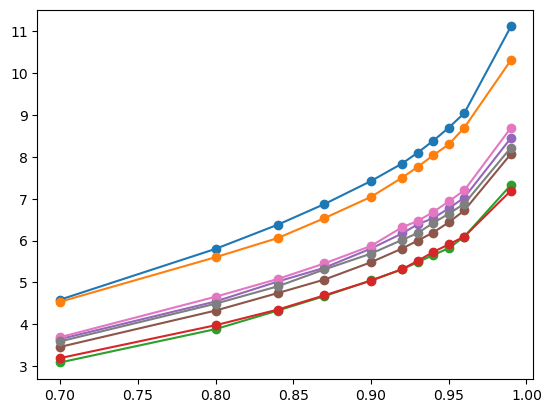

In [59]:
df = pd.read_csv(f"{BASE}/outputs/BI_acceptance_study.csv")
df["detector_id"] = df["channel"].apply(lambda x: channel_ID[channels.index(x)])
df.sort_values(["detector_id","acceptance"], inplace=True)
for id in df["detector_id"].unique():
    df_sub = df.loc[df["detector_id"]==id]
    plt.plot(df_sub["acceptance"],df_sub["BI"]*1e5,marker='o',label=f"Det. {id}")


In [35]:
DataMathieu = pd.read_csv("/local/home/mp274748/BackgroundBudgetMacros/PileupPlot/MathieuCurves.csv")

In [36]:
DataMathieu

,Analysis Type,Efficiency,Detector1,Detector2,Detector3,Detector4,Detector5,Detector6,Detector7,Detector8
0,M1,0.99,0.000113,0.000114,0.000071,0.000074,0.000087,0.000081,0.000091,0.000085
1,M1,0.96,0.000091,0.000092,0.000059,0.000060,0.000071,0.000065,0.000074,0.000071
2,M1,0.93,0.000081,0.000082,0.000053,0.000054,0.000062,0.000058,0.000065,0.000063
3,M1,0.90,0.000076,0.000075,0.000049,0.000049,0.000056,0.000052,0.000060,0.000058
4,M1,0.87,0.000068,0.000070,0.000046,0.000045,0.000052,0.000048,0.000055,0.000053
5,M1,0.84,0.000064,0.000064,0.000042,0.000042,0.000049,0.000044,0.000050,0.000050
6,M1,0.80,0.000058,0.000058,0.000039,0.000038,0.000044,0.000040,0.000046,0.000045
7,M1,0.70,0.000046,0.000047,0.000031,0.000031,0.000036,0.000031,0.000037,0.000036
8,M2,0.99,0.000120,0.000132,0.000077,0.000072,0.000088,0.000094,0.000092,0.000090
9,M2,0.96,0.000094,0.000106,0.000063,0.000058,0.000072,0.000070,0.000072,0.000072


In [63]:
df = pd.read_csv(f"{BASE}/outputs/BI_acceptance_study.csv")
df["detector_id"] = df["channel"].apply(lambda x: channel_ID[channels.index(x)])
df["detector_id"] = df["channel"].apply(lambda x: f"Detector{channels.index(x)+1}")
df.rename(columns={"acceptance": "Efficiency"}, inplace=True)
df.columns
df_pivot = df.pivot(index="Efficiency", columns="detector_id", values="BI")
df_pivot["Analysis Type"] = "mean"

df_pivot.to_csv("/local/home/mp274748/BackgroundBudgetMacros/PileupPlot/MathieuCurves_bis.csv")

In [62]:
df_pivot

detector_id,Detector0,Detector1,Detector2,Detector3,Detector4,Detector5,Detector6,Detector7,Analysis Type
Efficiency,,,,,,,,,
0.70,0.000032,0.000036,0.000037,0.000035,0.000031,0.000046,0.000036,0.000045,mean
0.80,0.000040,0.000045,0.000047,0.000043,0.000039,0.000058,0.000045,0.000056,mean
0.84,0.000043,0.000050,0.000051,0.000047,0.000043,0.000064,0.000049,0.000061,mean
0.87,0.000047,0.000053,0.000055,0.000051,0.000047,0.000069,0.000053,0.000065,mean
0.90,0.000050,0.000058,0.000059,0.000055,0.000050,0.000074,0.000057,0.000070,mean
0.92,0.000053,0.000062,0.000063,0.000058,0.000053,0.000078,0.000060,0.000075,mean
0.93,0.000055,0.000064,0.000065,0.000060,0.000055,0.000081,0.000062,0.000078,mean
0.94,0.000057,0.000065,0.000067,0.000062,0.000057,0.000084,0.000064,0.000080,mean
0.95,0.000059,0.000068,0.000069,0.000064,0.000058,0.000087,0.000066,0.000083,mean
